In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from scipy.signal import savgol_filter
from pykalman import KalmanFilter

In [2]:
%store -r cn0dbhz_merge_df
%store -r satcount_merge_df
%store -r elevationdeg_merge_df
%store -r acc_merge_df
%store -r gyro_merge_df
# %store -r energy_merge_df

%store -r satcountdelta_merge_df
# %store -r energydelta_merge_df
%store -r cn0dbhzdelta_merge_df
%store -r cn0dbhzmean_merge_df
# %store -r energystd_merge_df
# %store -r clarity_merge_df

In [3]:
print('Cn0DbHz Shape: ')
print(cn0dbhz_merge_df.shape)
print()
print('SatCount Shape: ')
print(satcount_merge_df.shape)
print()
print('SvElevationDegrees Shape: ')
print(elevationdeg_merge_df.shape)
print()
# print('Energy Shape: ')
# print(energy_merge_df.shape)
# print()

Cn0DbHz Shape: 
(157536, 7)

SatCount Shape: 
(157536, 7)

SvElevationDegrees Shape: 
(157536, 7)



In [4]:
merge_df = cn0dbhz_merge_df.merge(satcount_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SatCount']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(elevationdeg_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SvElevationDegrees']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(energy_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'TotalMotionEnergy']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(acc_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'AccMag']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(gyro_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'GyroMag']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')

merge_df = merge_df.merge(satcountdelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SatCountDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(cn0dbhzdelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'Cn0DbHzDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(energydelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'EnergyDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(cn0dbhzmean_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'Cn0DbHzMean']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(energystd_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'EnergyStd']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(clarity_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SignalClarity']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')

In [5]:
print(merge_df)

                   drive_id        device  UnixTimeMillis    Cn0DbHz  \
0       2020-06-10-US-MTV-2  GooglePixel4   1591819527443  28.467568   
1       2020-06-10-US-MTV-2  GooglePixel4   1591819528443  27.682500   
2       2020-06-10-US-MTV-2  GooglePixel4   1591819529443  29.392105   
3       2020-06-10-US-MTV-2  GooglePixel4   1591819530443  28.816216   
4       2020-06-10-US-MTV-2  GooglePixel4   1591819531443  29.752778   
...                     ...           ...             ...        ...   
157531  2021-12-28-US-MTV-1     XiaomiMi8   1640724240000  25.838720   
157532  2021-12-28-US-MTV-1     XiaomiMi8   1640724241000  25.711051   
157533  2021-12-28-US-MTV-1     XiaomiMi8   1640724242000  25.539480   
157534  2021-12-28-US-MTV-1     XiaomiMi8   1640724243000  25.792816   
157535  2021-12-28-US-MTV-1     XiaomiMi8   1640724244000  25.816935   

        ErrorXEcefMeters  ErrorYEcefMeters  ErrorZEcefMeters  SatCount  \
0               3.866797          5.441235         -3.629497 

In [6]:
print(merge_df.isna().sum())

drive_id               0
device                 0
UnixTimeMillis         0
Cn0DbHz                0
ErrorXEcefMeters       0
ErrorYEcefMeters       0
ErrorZEcefMeters       0
SatCount               0
SvElevationDegrees    22
AccMag                 0
GyroMag                0
SatCountDelta          0
Cn0DbHzDelta           0
Cn0DbHzMean            0
dtype: int64


In [7]:
# drop null values

# merge_df = merge_df.dropna(subset=['SvElevationDegrees', 'TotalMotionEnergy'])
merge_df = merge_df.dropna(subset=['SvElevationDegrees'])

print(merge_df.isna().sum())
print()
print('Merge Shape: ')
print(merge_df.shape)
print()

drive_id              0
device                0
UnixTimeMillis        0
Cn0DbHz               0
ErrorXEcefMeters      0
ErrorYEcefMeters      0
ErrorZEcefMeters      0
SatCount              0
SvElevationDegrees    0
AccMag                0
GyroMag               0
SatCountDelta         0
Cn0DbHzDelta          0
Cn0DbHzMean           0
dtype: int64

Merge Shape: 
(157514, 14)



In [8]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'AccMag', 'GyroMag', 'SatCountDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean']]
y = pd.Series(merge_df['ErrorXEcefMeters'])

In [9]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# train multiple linear regression model

modelx = LinearRegression()

modelx.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
print("Coefficients:", modelx.coef_)  
print("Intercept:", modelx.intercept_)

Coefficients: [-0.05767521  0.03681364  0.04645612  0.02123697 -0.77540224 -0.01325099
  0.01172119 -0.20238712]
Intercept: -1.9338382001638053


In [12]:
y_train_pred = modelx.predict(X_train)

In [13]:
y_test_pred = modelx.predict(X_test)

In [14]:
# metrics for train data

print('Goodness of Fit of Model \tTrain Dataset')
print("Explained Variance (R^2) \t:", modelx.score(X_train, y_train)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_train, y_train_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.041484357505053526
Mean Squared Error (MSE) 	: 3.6359986753161135
Root Mean Squared Error (RMSE) 	: 1.9068294824960395


In [15]:
# metrics for test data

print('Goodness of Fit of Model \tTest Dataset')
print("Explained Variance (R^2) \t:", modelx.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.03988326498861028
Mean Squared Error (MSE) 	: 3.7491187843994425
Root Mean Squared Error (RMSE) 	: 1.9362641308456454


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_48204/2859133257.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])


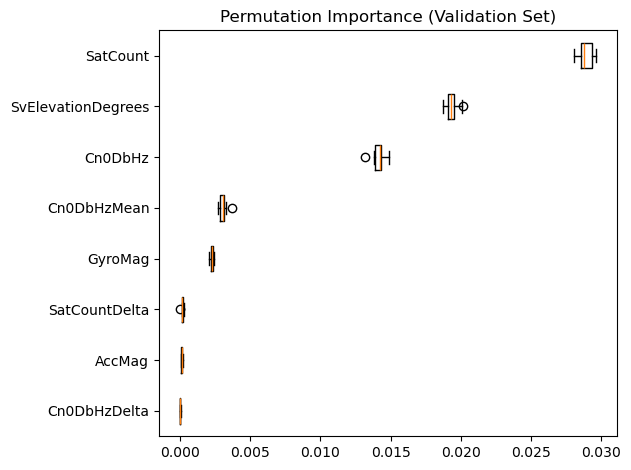

In [16]:
result = permutation_importance(
    modelx, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])
plt.title("Permutation Importance (Validation Set)")
plt.tight_layout()
plt.show()

In [17]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'AccMag', 'GyroMag', 'SatCountDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean']]
y = pd.Series(merge_df['ErrorYEcefMeters'])

In [18]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# train multiple linear regression model

modely = LinearRegression()

modely.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
print("Coefficients:", modely.coef_)  
print("Intercept:", modely.intercept_)

Coefficients: [-0.10374239 -0.04038135 -0.09657206  0.01737668 -0.17672058  0.00857611
  0.03880106 -0.11973419]
Intercept: 6.983786628298303


In [21]:
y_train_pred = modely.predict(X_train)

In [22]:
y_test_pred = modely.predict(X_test)

In [23]:
# metrics for train data

print('Goodness of Fit of Model \tTrain Dataset')
print("Explained Variance (R^2) \t:", modely.score(X_train, y_train)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_train, y_train_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.025934330172660447
Mean Squared Error (MSE) 	: 6.332373059723674
Root Mean Squared Error (RMSE) 	: 2.5164206841710057


In [24]:
# metrics for test data

print('Goodness of Fit of Model \tTest Dataset')
print("Explained Variance (R^2) \t:", modely.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.023239810074293987
Mean Squared Error (MSE) 	: 6.406015993632682
Root Mean Squared Error (RMSE) 	: 2.531010863989462


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_48204/4278546562.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])


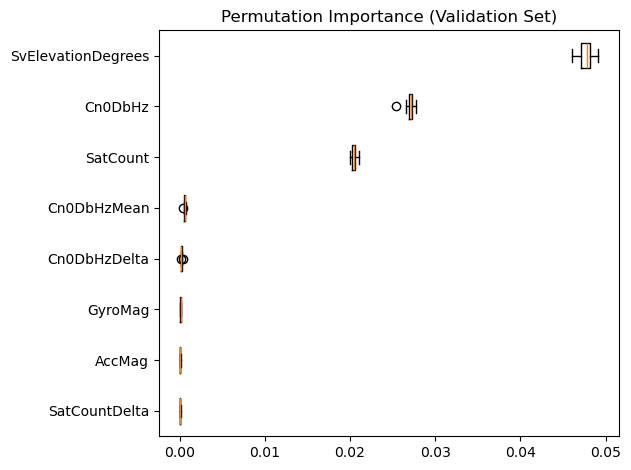

In [25]:
result = permutation_importance(
    modely, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])
plt.title("Permutation Importance (Validation Set)")
plt.tight_layout()
plt.show()

In [26]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'AccMag', 'GyroMag', 'SatCountDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean']]
y = pd.Series(merge_df['ErrorZEcefMeters'])

In [27]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# train multiple linear regression model

modelz = LinearRegression()

modelz.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
print("Coefficients:", modelz.coef_)  
print("Intercept:", modelz.intercept_)

Coefficients: [ 0.02254032 -0.02079368  0.03688051 -0.06256198 -0.14779357  0.01843918
 -0.00146096  0.20901305]
Intercept: -0.34508899801379433


In [30]:
y_train_pred = modelz.predict(X_train)

In [31]:
y_test_pred = modelz.predict(X_test)

In [32]:
# metrics for train data

print('Goodness of Fit of Model \tTrain Dataset')
print("Explained Variance (R^2) \t:", modelz.score(X_train, y_train)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_train, y_train_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.011539939846776037
Mean Squared Error (MSE) 	: 6.626912785391398
Root Mean Squared Error (RMSE) 	: 2.574279080711996


In [33]:
# metrics for test data

print('Goodness of Fit of Model \tTest Dataset')
print("Explained Variance (R^2) \t:", modelz.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.008914069704523575
Mean Squared Error (MSE) 	: 6.671164503172514
Root Mean Squared Error (RMSE) 	: 2.5828597529042328


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_48204/1873477217.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])


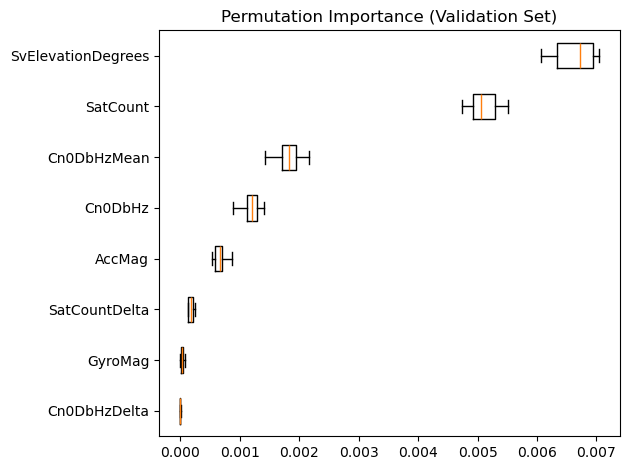

In [34]:
result = permutation_importance(
    modelz, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])
plt.title("Permutation Importance (Validation Set)")
plt.tight_layout()
plt.show()

In [35]:
%store -r merge_test_df

In [36]:
features_test_df = merge_test_df.drop(columns=['UnixTimeMillis', 'tripId', 'x_kf','y_kf', 'z_kf'])

predicted_errorx = modelx.predict(features_test_df)
predicted_errory = modely.predict(features_test_df)
predicted_errorz = modelz.predict(features_test_df)

print('predicted_errorx: ')
print(predicted_errorx)
print()
print('predicted_errory: ')
print(predicted_errory)
print()
print('predicted_errorz: ')
print(predicted_errorz)
print()

predicted_errorx: 
[-0.12265732 -0.13431689 -0.16158753 ... -1.36575947 -1.20018383
 -1.23655115]

predicted_errory: 
[-0.95755908 -0.96943892 -0.88687182 ... -0.58341363 -0.7623345
 -0.54752585]

predicted_errorz: 
[0.25644023 0.25363482 0.22448356 ... 0.84626492 0.81501871 0.70386688]



In [37]:
submission_ecef = pd.DataFrame()
submission_ecef['MeasurementX_Corr'] = merge_test_df['x_kf'] + predicted_errorx
submission_ecef['MeasurementY_Corr'] = merge_test_df['y_kf'] + predicted_errory
submission_ecef['MeasurementZ_Corr'] = merge_test_df['z_kf'] + predicted_errorz

In [38]:
transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)

lon, lat, alt = transformer.transform(
    submission_ecef['MeasurementX_Corr'].values, 
    submission_ecef['MeasurementY_Corr'].values,
    submission_ecef['MeasurementZ_Corr'].values,
)

In [39]:
submission = pd.DataFrame()
submission['tripId'] = merge_test_df['tripId']
submission['UnixTimeMillis'] = merge_test_df['UnixTimeMillis']
submission['LatitudeDegrees'] = lat
submission['LongitudeDegrees'] = lon
print(submission)
print()

                                          tripId  UnixTimeMillis  \
0      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650832999   
1      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650833999   
2      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650834999   
3      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650835999   
4      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650836999   
...                                          ...             ...   
66092           2022-04-25-US-OAK-2/GooglePixel4   1650927742650   
66093           2022-04-25-US-OAK-2/GooglePixel4   1650927743642   
66094           2022-04-25-US-OAK-2/GooglePixel4   1650927744651   
66095           2022-04-25-US-OAK-2/GooglePixel4   1650927745640   
66096           2022-04-25-US-OAK-2/GooglePixel4   1650927746632   

       LatitudeDegrees  LongitudeDegrees  
0            37.395759       -122.102965  
1            37.395758       -122.102965  
2            37.395758       -122.102966  
3          

In [40]:
def remove_spikes(df):
    dist_lat = df.groupby('tripId')['LatitudeDegrees'].diff().abs()
    dist_lng = df.groupby('tripId')['LongitudeDegrees'].diff().abs()
    
    mask = (dist_lat > 0.0005) | (dist_lng > 0.0005)
    
    df.loc[mask, ['LatitudeDegrees', 'LongitudeDegrees']] = np.nan
    
    return df.groupby('tripId').apply(lambda group: group.interpolate())

In [41]:
def apply_savgol_filter(df, window=11, poly=3):
    df = df.reset_index(drop=True)
    df_out = df.copy()
    
    for trip_id, trip_df in df_out.groupby('tripId'):
        
        if len(trip_df) > window:
            df_out.loc[trip_df.index, 'LatitudeDegrees'] = savgol_filter(trip_df['LatitudeDegrees'], window, poly)
            df_out.loc[trip_df.index, 'LongitudeDegrees'] = savgol_filter(trip_df['LongitudeDegrees'], window, poly)
    
    return df_out

In [42]:
submission = remove_spikes(submission)
submission = apply_savgol_filter(submission)

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_48204/2132394206.py:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.groupby('tripId').apply(lambda group: group.interpolate())
/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_48204/2132394206.py:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.groupby('tripId').apply(lambda group: group.interpolate())
/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_48204/2132394206.py:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.groupby('tripId').apply(lambda group: group.interpolate())
/var/folders/w8/d9x92py92j792gw

In [43]:
print(submission)
print()
submission.to_csv('./SUBMISSIONS/LINEAR_REGRESSION/submission.csv', index=False)

                                          tripId  UnixTimeMillis  \
0      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650832999   
1      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650833999   
2      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650834999   
3      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650835999   
4      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650836999   
...                                          ...             ...   
66092           2022-04-25-US-OAK-2/GooglePixel4   1650927742650   
66093           2022-04-25-US-OAK-2/GooglePixel4   1650927743642   
66094           2022-04-25-US-OAK-2/GooglePixel4   1650927744651   
66095           2022-04-25-US-OAK-2/GooglePixel4   1650927745640   
66096           2022-04-25-US-OAK-2/GooglePixel4   1650927746632   

       LatitudeDegrees  LongitudeDegrees  
0            37.395758       -122.102963  
1            37.395759       -122.102968  
2            37.395759       -122.102967  
3          

In [44]:
print(merge_test_df.isna().sum())

UnixTimeMillis        0
Cn0DbHz               0
SatCount              0
SvElevationDegrees    0
tripId                0
AccMag                0
GyroMag               0
SatCountDelta         0
Cn0DbHzDelta          0
Cn0DbHzMean           0
x_kf                  0
y_kf                  0
z_kf                  0
dtype: int64


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_48204/2859133257.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])


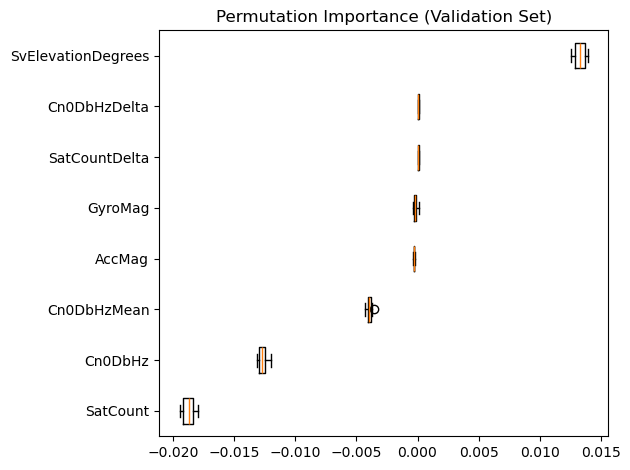

In [45]:
result = permutation_importance(
    modelx, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])
plt.title("Permutation Importance (Validation Set)")
plt.tight_layout()
plt.show()